In [1]:
import numpy as np

from easydynamics.Job import Job
from easydynamics.Experiment import Experiment
from easydynamics.Experiment import Data

from easydynamics.sample import BrownianTranslationalDiffusion

from easydynamics.sample import SampleModel
from easydynamics.sample import Lorentzian
from easydynamics.sample import DeltaFunction
from easydynamics.sample import Polynomial

from easydynamics.sample import Gaussian

from easydynamics.resolution import ResolutionHandler


import scipp as sc

import plopp as pp

%matplotlib widget

In [2]:
# Create some fake data
Q=np.linspace(0.1,2,16)
E=np.linspace(-5,5,201)

resolution_width=np.ones_like(Q)*0.1+0.005*np.random.normal(size=len(Q))

diffusion_coefficients=[0.1,0.25,0.5,0.75]
convoluted_signal=np.zeros((len(Q),len(E)))

scale=0.7 #arbitrary scale factor for diffusion model

T=3

model=BrownianTranslationalDiffusion(name="DiffusionModel", diffusion_coefficient=diffusion_coefficients[T])
HWHM=model.calculate_width(Q)

QQISF=model.calculate_QISF(Q)
EISF=model.calculate_EISF(Q)


resolution_handler=ResolutionHandler()

sample_model=[]
for i in range(len(Q)):
    sample_model.append(SampleModel(name=f"SampleModel_{i}"))

    sample_model[i].add_component(DeltaFunction(area=scale*EISF[i]+0.23, name="Elastic"))
    sample_model[i].add_component(Lorentzian(area=scale*QQISF[i], name="QuasiElastic", width=HWHM[i]) )
    resolution=Gaussian(name="Resolution", area=1,width=resolution_width[i])

    convoluted_signal[i,:] = resolution_handler.convolve(E,sample_model[i],resolution)+0.05+0.01*np.random.normal(size=len(E))



Q_scipp=sc.array(dims=['Q'],values=Q, unit='1/angstrom')
E_scipp=sc.array(dims=['energy'],values=E,unit='meV')
intensity_scipp=sc.array(dims=['Q','energy'],values=convoluted_signal,variances=0.01*convoluted_signal)

diffusion_data = sc.DataArray(data=intensity_scipp, coords={'Q':Q_scipp,'energy': E_scipp})

sc.io.hdf5.save_hdf5(diffusion_data, "diffusion_data_example.h5")

In [3]:

vanadium_signal=np.zeros((len(Q),len(E)))

scale=0.52 #arbitrary scale factor for vanadium

vanadium_model=Gaussian(name="Vanadium", area=1,width=0.1)


sample_model=[]
for i in range(len(Q)):

    vanadium_signal[i,:] = vanadium_model.evaluate(E)*scale+0.11+0.03*np.random.normal(size=len(E))

vanadium_signal[vanadium_signal<0]=0.03

Q_scipp=sc.array(dims=['Q'],values=Q, unit='1/angstrom')
E_scipp=sc.array(dims=['energy'],values=E,unit='meV')
intensity_scipp=sc.array(dims=['Q','energy'],values=vanadium_signal,variances=0.02*vanadium_signal)

vanadium_data = sc.DataArray(data=intensity_scipp, coords={'Q':Q_scipp,'energy': E_scipp})
sc.io.hdf5.save_hdf5(vanadium_data, "vanadium_data_example.h5")

In [4]:
pp.slicer(diffusion_data.transpose(),coords=['energy','Q'],keep=['energy'])




InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [5]:
pp.slicer(vanadium_data.transpose(),coords=['energy','Q'],keep=['energy'])




vanadium_job= Job(name='Vanadium')


exp=Experiment()
data=Data()
data.append(vanadium_data)

exp.set_data(data)

vanadium_job.set_experiment(exp)
# vanadium_job.generate_empty_analysis_array()


bg=SampleModel('Background')
bg.add_component(Polynomial(coefficients=[0.1]))
vanadium_job.set_background_model(bg)
# vanadium_job.set_background_model_for_all_analyses()



vanadium_model=SampleModel(name="VanadiumModel")
vanadium_model.add_component(Gaussian(name="Resolution", area=0.4,width=0.1))
vanadium_job.set_theory(vanadium_model)
# vanadium_job.set_theory_for_all_analyses()
vanadium_job.generate_analysis_for_cuts()



Job `Vanadium`

In [6]:
vanadium_job.plot_data_and_model(intensity_min=0.0, intensity_max=2.5,
                            energy_min=-5, energy_max=5)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [7]:
vanadium_job.fit()

vanadium_job.plot_data_and_model(intensity_min=0.0, intensity_max=2.5,
                            energy_min=-5, energy_max=5)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [8]:
vanadium_job.plot_fit_parameters('Resolution width')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [9]:
diffusion_job_sequential= Job(name='BrownianDiffusionSequential')

exp=Experiment()
data=Data()
data.append(diffusion_data)
exp.set_data(data)
diffusion_job_sequential.set_experiment(exp)


bg=SampleModel('Background')
bg.add_component(Polynomial(name='BG',coefficients=[0.1]))
diffusion_job_sequential.set_background_model(bg)

sequential_model=SampleModel(name="SequentialModel")
sequential_model.add_component(Lorentzian(name="QuasiElastic", area=1.0, width=0.5))
sequential_model.add_component(DeltaFunction(name="Elastic", area=0.2))
diffusion_job_sequential.set_theory(sequential_model)

diffusion_job_sequential.generate_analysis_for_cuts()

diffusion_job_sequential.use_fit_as_resolution(vanadium_job)

diffusion_job_sequential.plot_data_and_model(intensity_min=0.0, intensity_max=4,
                            energy_min=-5, energy_max=5)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [10]:

diffusion_job_sequential.fit()
diffusion_job_sequential.plot_data_and_model(intensity_min=0.0, intensity_max=2,
                            energy_min=-5, energy_max=5)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [11]:
diffusion_job_sequential.plot_fit_parameters("QuasiElastic width")

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

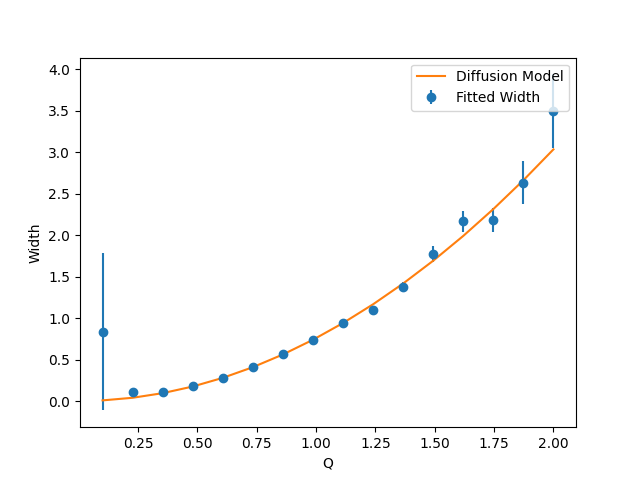

In [12]:
diffusion_job_sequential._diffusion_model=BrownianTranslationalDiffusion(name="DiffusionModel", diffusion_coefficient=0.3,scale=1.0)
fit_result=diffusion_job_sequential.fit_diffusion_width("QuasiElastic width")
diffusion_job_sequential.plot_diffusion_fit_result("QuasiElastic width")

In [13]:
diffusion_job_sequential._analysis[5].get_parameters()

[<Parameter 'QuasiElastic area': 0.6943 ± 0.0124 meV, bounds=[-inf:inf]>,
 <Parameter 'QuasiElastic center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'QuasiElastic width': 0.4141 ± 0.0160 meV, bounds=[0.0:inf]>,
 <Parameter 'Elastic area': 0.2376 ± 0.0092 meV, bounds=[0.0:inf]>,
 <Parameter 'Elastic center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution area': 1.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution width': 0.1013 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'BG_c0': 0.0485 ± 0.0010, bounds=[-inf:inf]>,
 <Parameter 'offset': 1.422e-05 ± 2.584e-03 meV, bounds=[-inf:inf]>]

In [14]:
diffusion_job_sequential._diffusion_model.get_parameters()

[<Parameter 'diffusion_coefficient': 0.7584 ± 0.0103, bounds=[-inf:inf]>,
 <Parameter 'scale': 1.0000, bounds=[-inf:inf]>]

In [15]:


diffusion_job= Job(name='BrownianDiffusion')


exp=Experiment()
data=Data()
data.append(diffusion_data)

exp.set_data(data)

diffusion_job.set_experiment(exp)
diffusion_job.generate_empty_analysis_array()


bg=SampleModel('Background')
bg.add_component(Polynomial(coefficients=[0.5]))
diffusion_job.set_background_model(bg)
diffusion_job.set_background_model_for_all_analyses()

resolution=SampleModel()
resolution.add_component(Gaussian(name="Resolution", area=1,width=0.1))
diffusion_job.set_resolution_model(resolution)
diffusion_job.set_resolution_model_for_all_analyses()




diffusion_model=BrownianTranslationalDiffusion(name="DiffusionModel", diffusion_coefficient=0.3,scale=1.0)
diffusion_job.set_diffusion_model(diffusion_model)
delta_model=DeltaFunction(name="Delta",area=0.2)
diffusion_job.set_theory_for_all_analyses(delta_model)


In [16]:
diffusion_job.analysis[5].get_parameters()

[<Parameter 'scale': 1.0000, bounds=[-inf:inf]>,
 <Parameter 'Lorentzian center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gamma': 0.1613, bounds=[-inf:inf]>,
 <Parameter 'Delta area': 0.2000 meV, bounds=[0.0:inf]>,
 <Parameter 'Delta center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'diffusion_coefficient': 0.3000, bounds=[-inf:inf]>,
 <Parameter 'scale': 1.0000, bounds=[-inf:inf]>,
 <Parameter 'Resolution area': 1.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution width': 0.1000 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'Polynomial_c0': 0.5000, bounds=[-inf:inf]>,
 <Parameter 'offset': 0.0000 meV, bounds=[-inf:inf]>]

In [17]:
diffusion_job.analysis[5].get_fit_parameters()

[<Parameter 'scale': 1.0000, bounds=[-inf:inf]>,
 <Parameter 'Delta area': 0.2000 meV, bounds=[0.0:inf]>,
 <Parameter 'diffusion_coefficient': 0.3000, bounds=[-inf:inf]>,
 <Parameter 'scale': 1.0000, bounds=[-inf:inf]>,
 <Parameter 'Polynomial_c0': 0.5000, bounds=[-inf:inf]>,
 <Parameter 'offset': 0.0000 meV, bounds=[-inf:inf]>]

In [18]:
diffusion_job.plot_data_and_model(intensity_min=0.0, intensity_max=4,
                            energy_min=-5, energy_max=5)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [19]:
result=diffusion_job.fit_simultaneous()


In [20]:
diffusion_job.plot_data_and_model(intensity_min=0.0, intensity_max=2,
                            energy_min=-5, energy_max=5)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [21]:
diffusion_job.analysis[5].get_parameters()

[<Parameter 'scale': 0.6996 ± 0.0035, bounds=[-inf:inf]>,
 <Parameter 'Lorentzian center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gamma': 0.3991 ± 0.0032, bounds=[-inf:inf]>,
 <Parameter 'Delta area': 0.2303 ± 0.0015 meV, bounds=[0.0:inf]>,
 <Parameter 'Delta center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'diffusion_coefficient': 0.7421 ± 0.0060, bounds=[-inf:inf]>,
 <Parameter 'scale': 0.6996 ± 0.0035, bounds=[-inf:inf]>,
 <Parameter 'Resolution area': 1.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution width': 0.1000 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'Polynomial_c0': 0.0489 ± 0.0007, bounds=[-inf:inf]>,
 <Parameter 'offset': -9.367e-07 ± 2.470e-03 meV, bounds=[-inf:inf]>]

In [22]:
diffusion_job.analysis[5].get_fit_parameters()

[<Parameter 'scale': 0.6996 ± 0.0035, bounds=[-inf:inf]>,
 <Parameter 'Delta area': 0.2303 ± 0.0015 meV, bounds=[0.0:inf]>,
 <Parameter 'diffusion_coefficient': 0.7421 ± 0.0060, bounds=[-inf:inf]>,
 <Parameter 'scale': 0.6996 ± 0.0035, bounds=[-inf:inf]>,
 <Parameter 'Polynomial_c0': 0.0489 ± 0.0007, bounds=[-inf:inf]>,
 <Parameter 'offset': -9.367e-07 ± 2.470e-03 meV, bounds=[-inf:inf]>]

In [23]:
diffusion_job_sequential._diffusion_model.get_parameters()

[<Parameter 'diffusion_coefficient': 0.7584 ± 0.0103, bounds=[-inf:inf]>,
 <Parameter 'scale': 1.0000, bounds=[-inf:inf]>]

In [24]:
diffusion_job_sequential.analysis[5].get_parameters()

[<Parameter 'QuasiElastic area': 0.6943 ± 0.0124 meV, bounds=[-inf:inf]>,
 <Parameter 'QuasiElastic center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'QuasiElastic width': 0.4141 ± 0.0160 meV, bounds=[0.0:inf]>,
 <Parameter 'Elastic area': 0.2376 ± 0.0092 meV, bounds=[0.0:inf]>,
 <Parameter 'Elastic center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution area': 1.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Resolution width': 0.1013 meV (fixed), bounds=[0.0:inf]>,
 <Parameter 'BG_c0': 0.0485 ± 0.0010, bounds=[-inf:inf]>,
 <Parameter 'offset': 1.422e-05 ± 2.584e-03 meV, bounds=[-inf:inf]>]